In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath("src"))

# Učitavanje podataka
df = pd.read_csv("data/podaci.csv")
df.head()

,ID,Name,Age,Gender,Location,School_Grade,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,...,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Phone_Usage_Purpose,Family_Communication,Weekend_Usage_Hours,Addiction_Level
0,1,Shannon Francis,13,Female,Hansonfort,9th,4.0,6.1,78,5,...,1.4,86,19,3.6,1.7,1.2,Browsing,4,8.7,10.0
1,2,Scott Rodriguez,17,Female,Theodorefort,7th,5.5,6.5,70,5,...,0.9,96,9,1.1,4.0,1.8,Browsing,2,5.3,10.0
2,3,Adrian Knox,13,Other,Lindseystad,11th,5.8,5.5,93,8,...,0.5,137,8,0.3,1.5,0.4,Education,6,5.7,9.2
3,4,Brittany Hamilton,18,Female,West Anthony,12th,3.1,3.9,78,8,...,1.4,128,7,3.1,1.6,0.8,Social Media,8,3.0,9.8
4,5,Steven Smith,14,Other,Port Lindsaystad,9th,2.5,6.7,56,4,...,1.0,96,20,2.6,0.9,1.1,Gaming,10,3.7,8.6


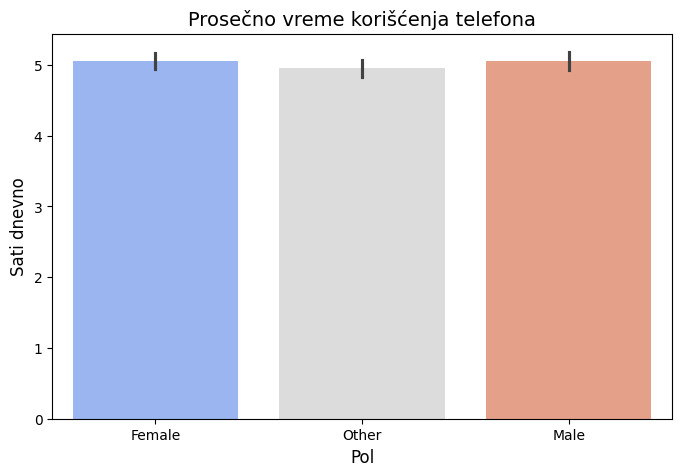

In [4]:
# Bar plot: Prosečno vreme korišćenja telefona u odnosu na pol
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='Gender', y='Daily_Usage_Hours', palette='coolwarm', hue='Gender', legend=False)
plt.title('Prosečno vreme korišćenja telefona', fontsize=14)
plt.ylabel('Sati dnevno', fontsize=12)
plt.xlabel('Pol', fontsize=12)
plt.show()

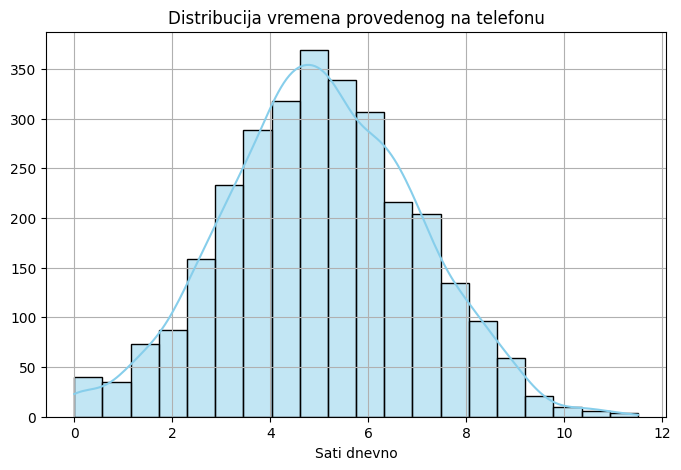

In [5]:
# Distribucija koriscenja telefona Screen Time
plt.figure(figsize=(8,5))
sns.histplot(df['Daily_Usage_Hours'], kde=True, bins=20, color='skyblue')
plt.title('Distribucija vremena provedenog na telefonu')
plt.xlabel('Sati dnevno')
plt.ylabel('')
plt.grid(True)
plt.show()

C:\Users\Strahinja\AppData\Local\Temp\ipykernel_9312\1127280339.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Age', y='Time_on_Social_Media', palette='muted')


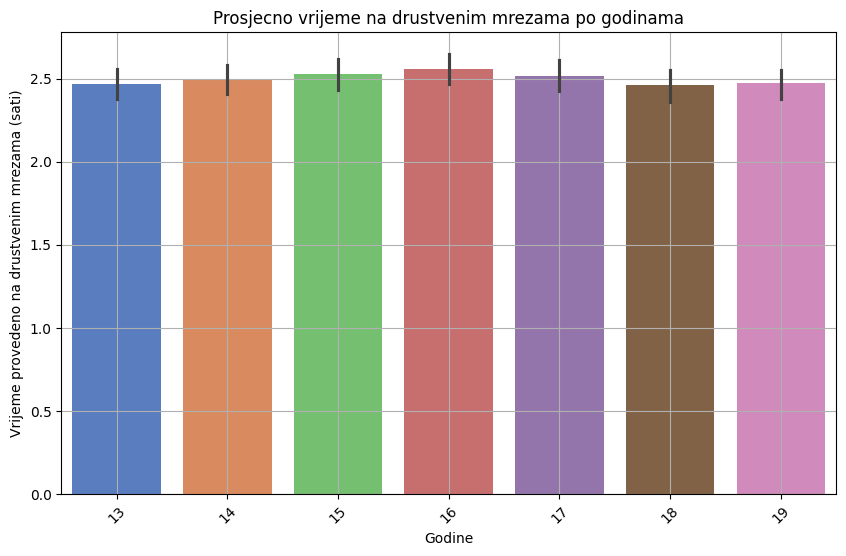

In [6]:
# Vrijeme provedeno na drustvenim mrezama po godinama
plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Age', y='Time_on_Social_Media', palette='muted')
plt.title('Prosjecno vrijeme na drustvenim mrezama po godinama')
plt.xlabel('Godine')
plt.ylabel('Vrijeme provedeno na drustvenim mrezama (sati)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

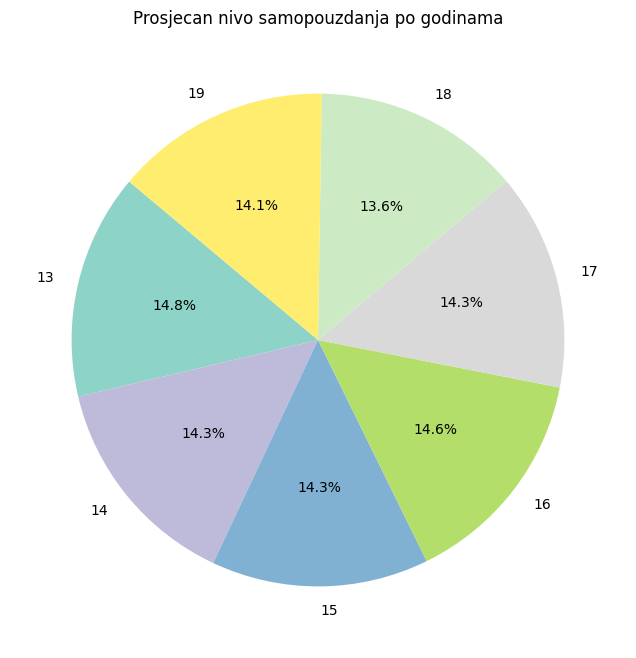

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [7]:
# Prosjecan nivo samopouzdanja po godinama
plt.figure(figsize=(8,8))

# Group by Age i izracnaj prosjecan Self_Esteem
age_self_esteem = df.groupby('Age')['Self_Esteem'].mean()

age_self_esteem.plot.pie(autopct='%1.1f%%', startangle=140, cmap='Set3')
plt.title('Prosjecan nivo samopouzdanja po godinama')
plt.ylabel('')
plt.show()

plt.figure(figsize=(10, 6))

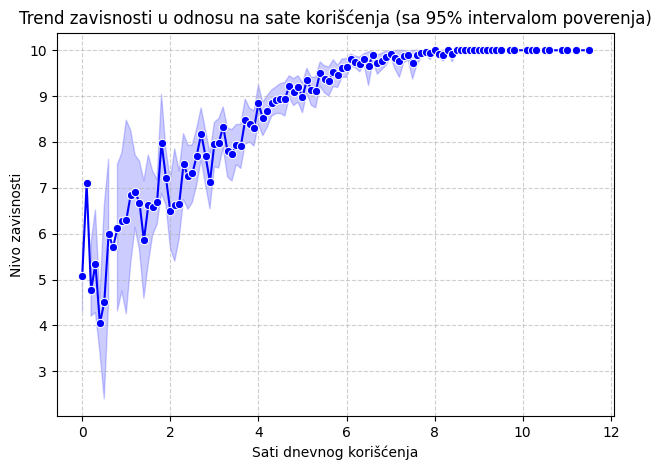

In [8]:
# Seaborn ce sam izracunati prosek i dodati interval poverenja (senku).
sns.lineplot(data=df, x='Daily_Usage_Hours', y='Addiction_Level', marker='o', color='blue', errorbar=('ci', 95))

plt.title('Trend zavisnosti u odnosu na sate korišćenja (sa 95% intervalom poverenja)')
plt.xlabel('Sati dnevnog korišćenja')
plt.ylabel('Nivo zavisnosti')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

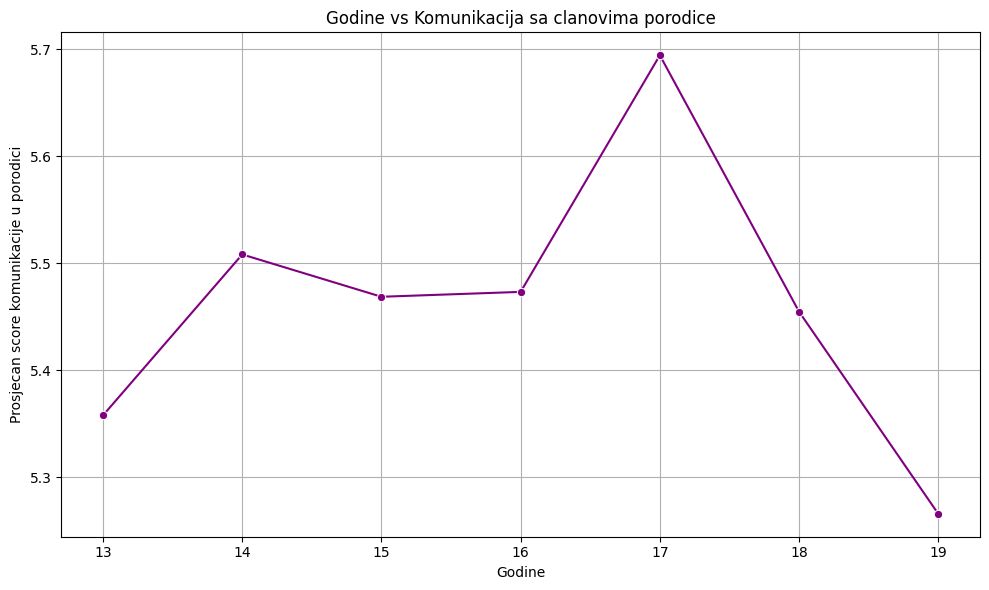

In [9]:
# Group by Age da bi se dobio Family_Communication po godinama
grouped_df = df.groupby('Age')['Family_Communication'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=grouped_df, x='Age', y='Family_Communication', marker='o', color='purple')
plt.title('Godine vs Komunikacija sa clanovima porodice')
plt.xlabel('Godine')
plt.ylabel('Prosjecan score komunikacije u porodici')
plt.grid(True)
plt.tight_layout()
plt.show()

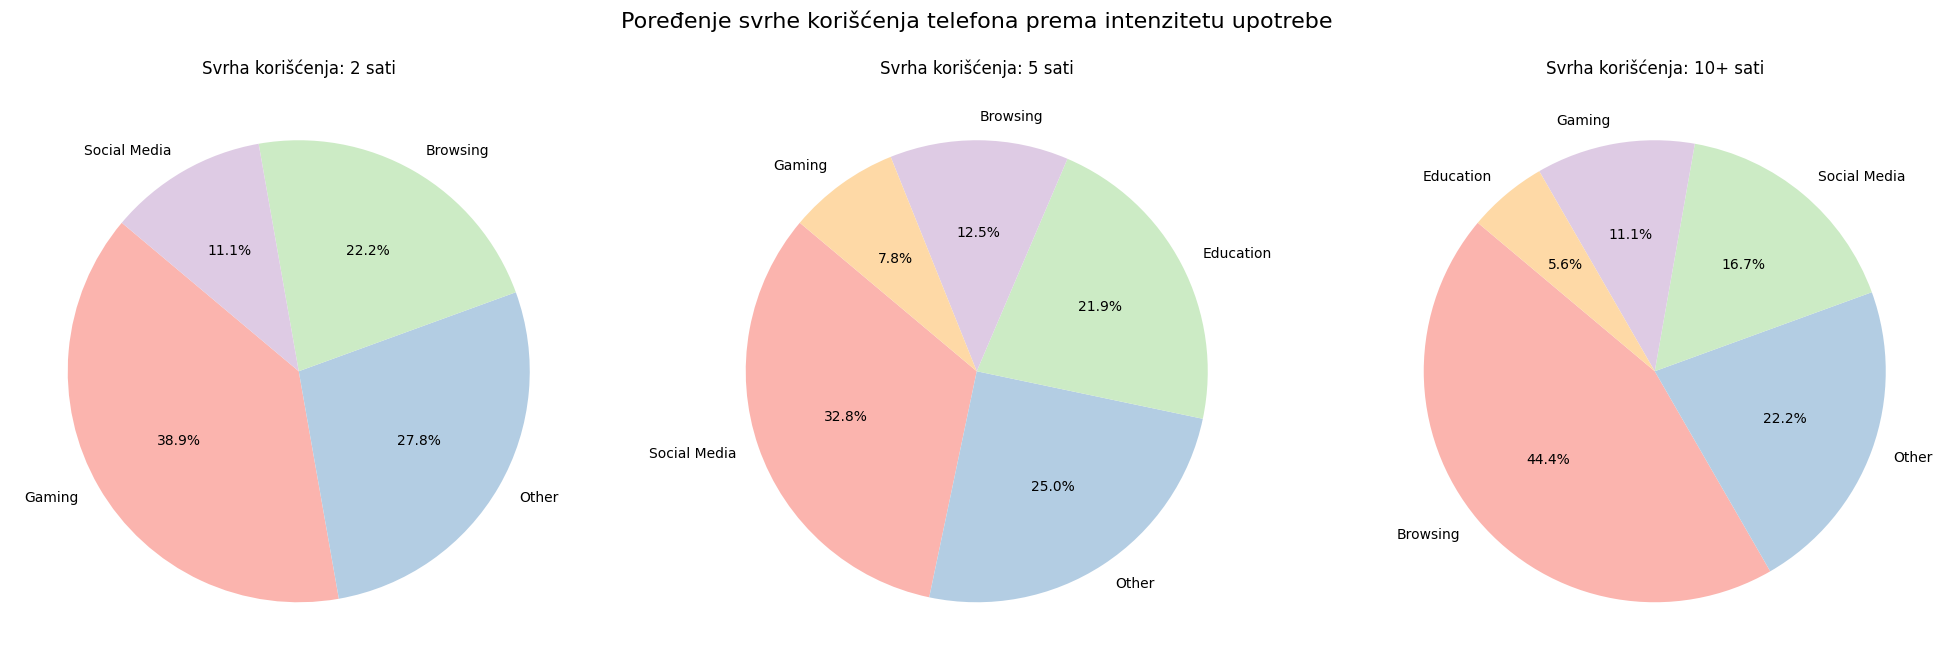

In [10]:
# Svrhe koriscenja telefona - hipoteza o intenzitetu
hours_to_compare = [2, 5, 10] # 10 će nam služiti kao '10 i više'
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for i, hr in enumerate(hours_to_compare):
    if hr == 10:
        filtered_df = df[df['Daily_Usage_Hours'] >= 10]
        title_suffix = "10+ sati"
    else:
        filtered_df = df[df['Daily_Usage_Hours'] == hr]
        title_suffix = f"{hr} sati"

    counts = filtered_df['Phone_Usage_Purpose'].value_counts()

    axes[i].pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140,
                colors=plt.cm.Pastel1.colors)
    axes[i].set_title(f'Svrha korišćenja: {title_suffix}')

plt.suptitle('Poređenje svrhe korišćenja telefona prema intenzitetu upotrebe', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

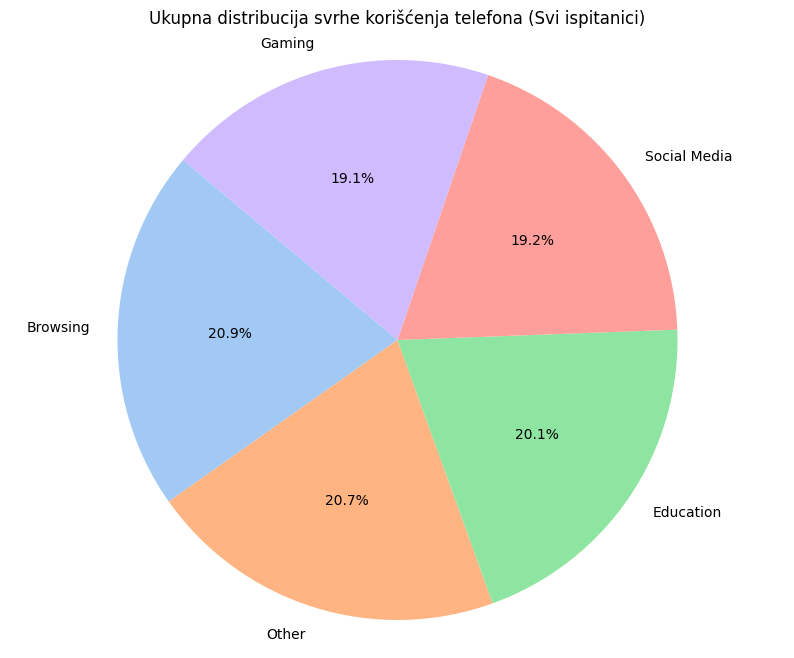

In [11]:
# Izračunavanje ukupne distribucije
overall_counts = df['Phone_Usage_Purpose'].value_counts()

plt.figure(figsize=(10, 8))
plt.pie(overall_counts,
        labels=overall_counts.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=sns.color_palette('pastel'))
plt.title('Ukupna distribucija svrhe korišćenja telefona (Svi ispitanici)')
plt.axis('equal')

plt.show()

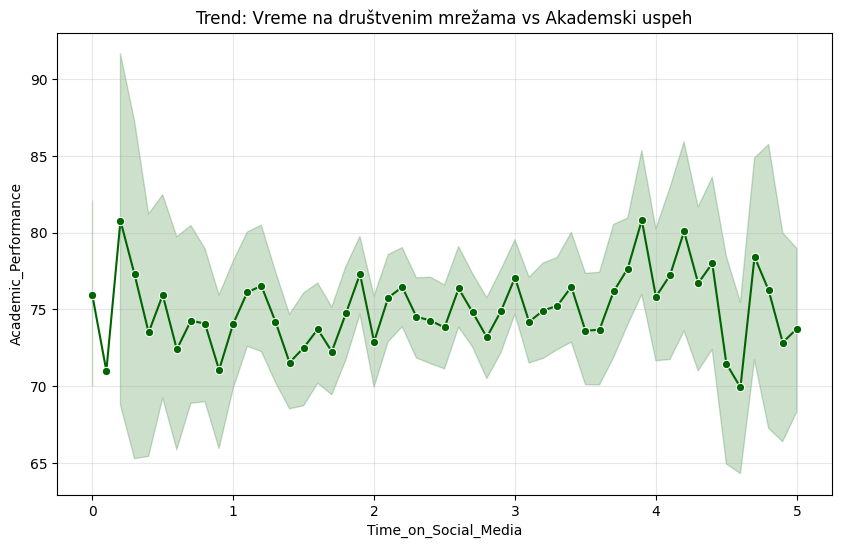

In [12]:
# Uticaj vremena na drustvenim mrezama na usojeh u skoli
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='Time_on_Social_Media', y='Academic_Performance',
             marker='o', color='darkgreen', errorbar=('ci', 95))

plt.title('Trend: Vreme na društvenim mrežama vs Akademski uspeh')
plt.grid(True, alpha=0.3)
plt.show()

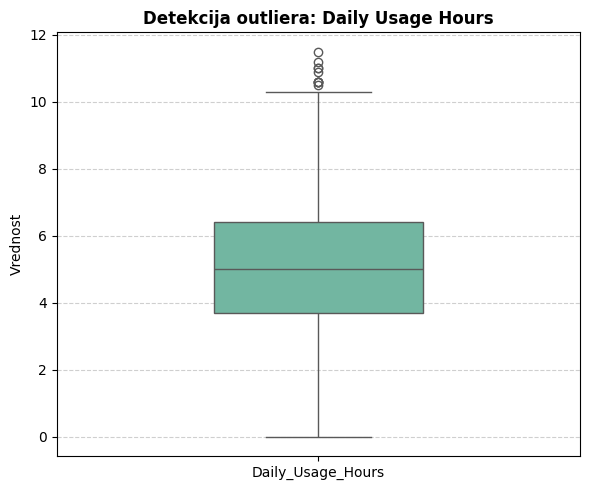

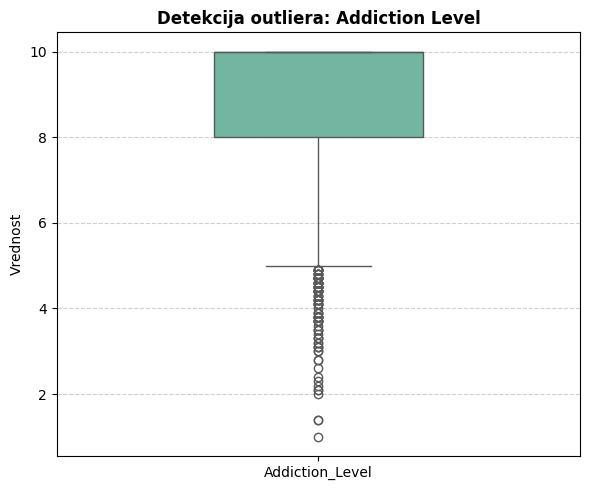

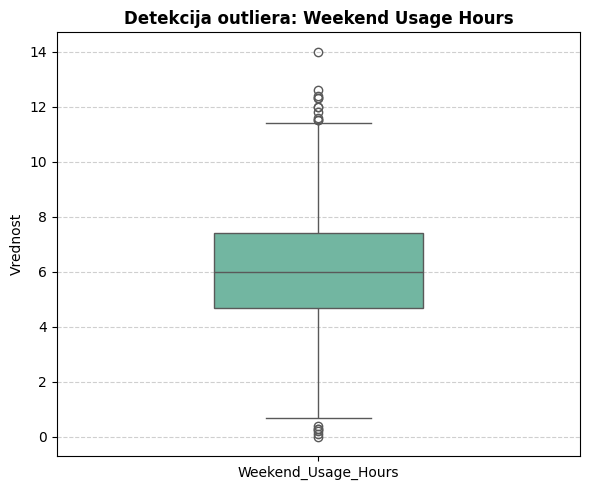

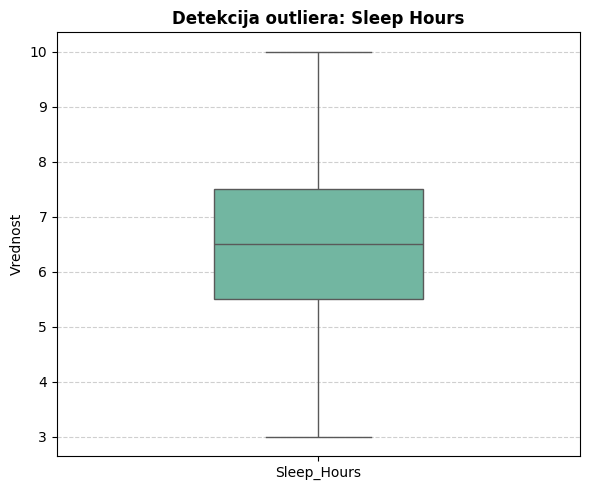

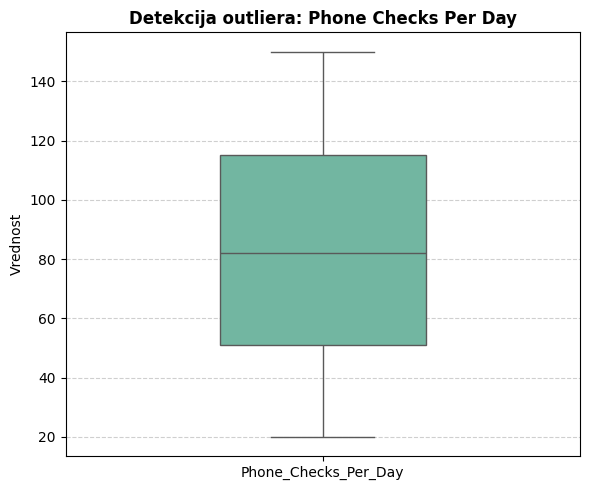

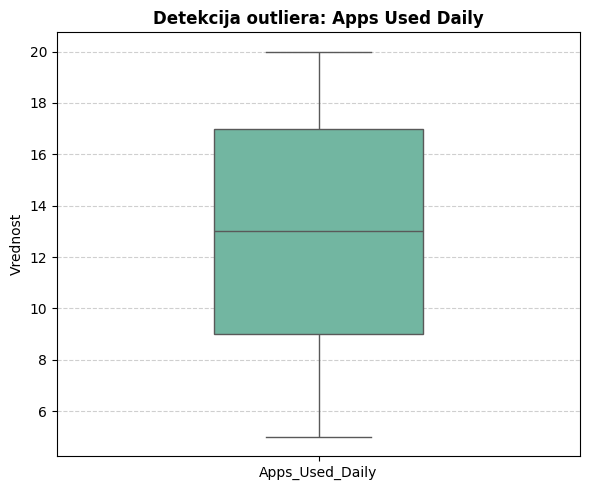

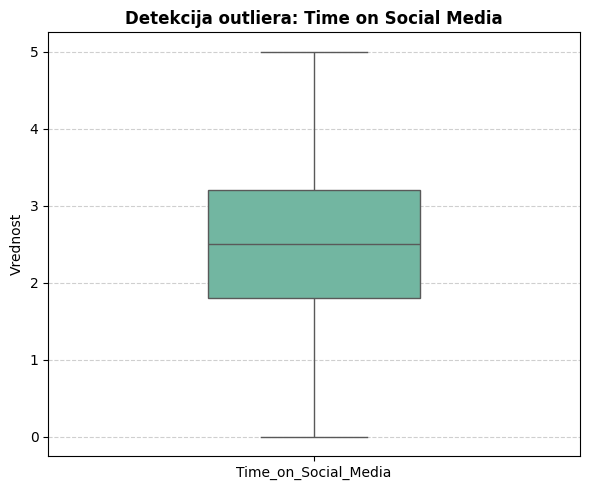

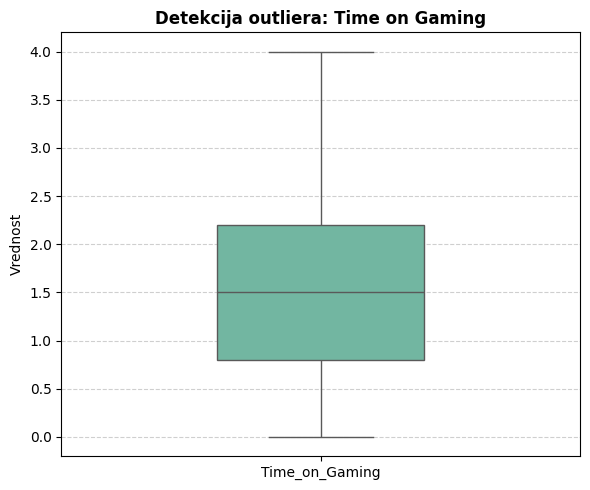

In [13]:
# Box plotovi
def plot_single_boxplot(df, column_name):

    if column_name not in df.columns:
        print(f"Greška: Kolona '{column_name}' ne postoji u DataFrame-u.")
        return

    if not pd.api.types.is_numeric_dtype(df[column_name]):
        print(f"Greška: Kolona '{column_name}' nije numerička i ne može se nacrtati boxplot.")
        return

    plt.figure(figsize=(6, 5))

    sns.boxplot(y=df[column_name],
                x=[column_name]*len(df),
                palette='Set2',
                width=0.4,
                hue=[column_name]*len(df),
                legend=False)

    clean_title = column_name.replace('_', ' ')
    plt.title(f'Detekcija outliera: {clean_title}', fontsize=12, fontweight='bold')
    plt.ylabel('Vrednost')
    plt.xlabel('') # Brišemo x-label jer je naziv već u naslovu
    plt.grid(axis='y', linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

plot_single_boxplot(df, 'Daily_Usage_Hours')
plot_single_boxplot(df, 'Addiction_Level')
plot_single_boxplot(df, 'Weekend_Usage_Hours')
plot_single_boxplot(df, 'Sleep_Hours')
plot_single_boxplot(df, 'Phone_Checks_Per_Day')
plot_single_boxplot(df, 'Apps_Used_Daily')
plot_single_boxplot(df, 'Time_on_Social_Media')
plot_single_boxplot(df, 'Time_on_Gaming')

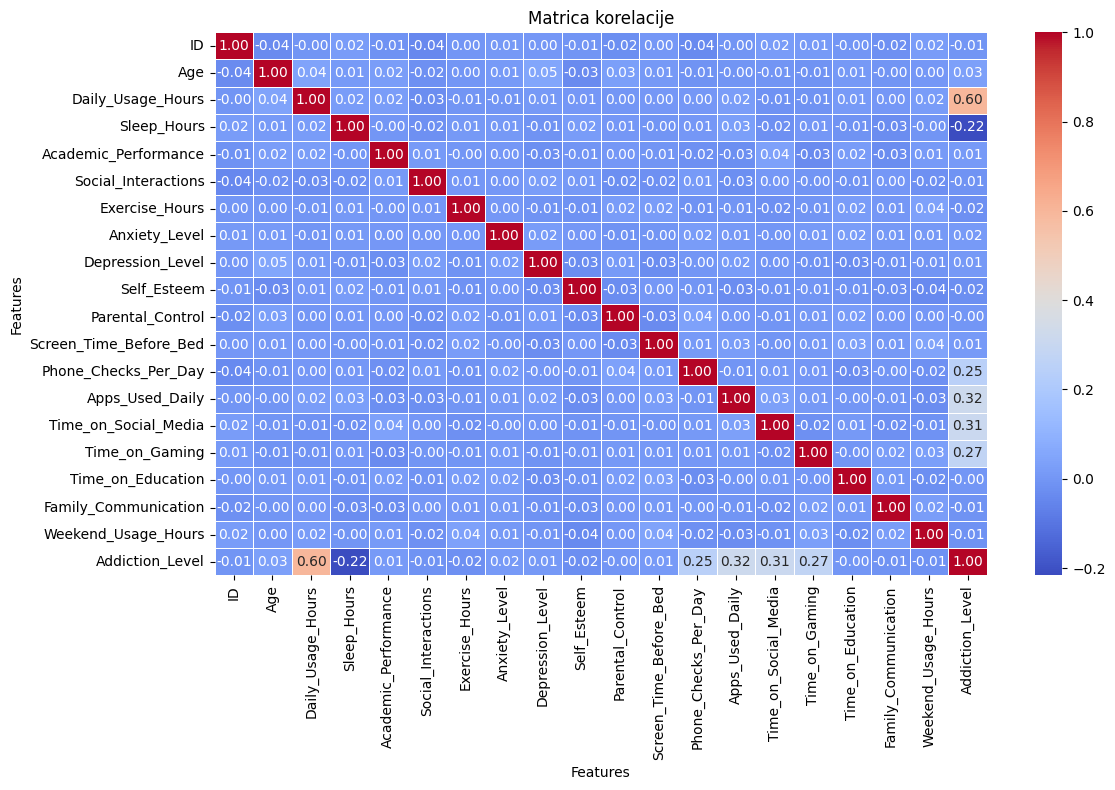

In [14]:
# Matrica korelacije
correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Matrica korelacije")
plt.xlabel("Features")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

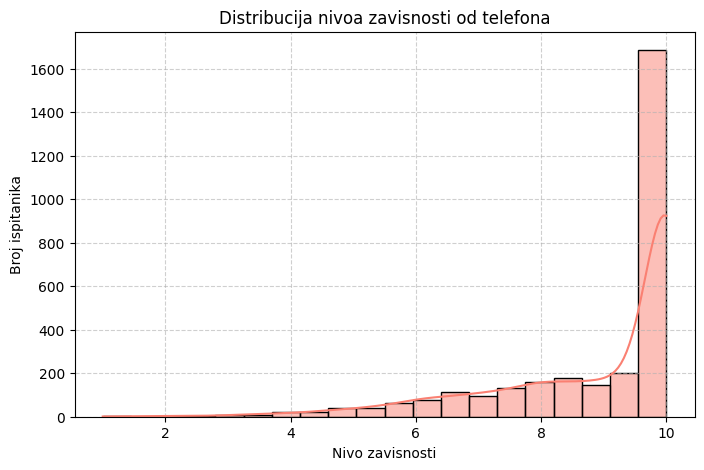

In [15]:
# Distribucija target varijable - Addiction Level
# Distribucija nivoa zavisnosti pokazuje da je većina ispitanika u datasetu na visokom nivou zavisnosti (9–10).
# Distribucija je asimetrična i naglašena prema većim vrednostima, što može uticati na performanse modela i dovesti do pristrasnosti u predviđanju.
plt.figure(figsize=(8,5))
sns.histplot(df['Addiction_Level'], bins=20, kde=True, color='salmon')

plt.title('Distribucija nivoa zavisnosti od telefona')
plt.xlabel('Nivo zavisnosti')
plt.ylabel('Broj ispitanika')

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()